# MobileNetV2 Training — Produce Quality Assessment

Fine-tunes MobileNetV2 on the Fruit and Vegetable Diseases Dataset to assess produce quality (healthy vs rotten) across 14 produce types (28 classes). Training uses a frozen-backbone Phase 1 followed by partial fine-tuning in Phase 2; hyperparameters are chosen via Keras Tuner Hyperband before Phase 1 begins.

## Google Drive Setup

In [3]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')

print(f'Drive root : {DRIVE_ROOT}')
print(f'Exists     : {DRIVE_ROOT.exists()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root : /content/drive/MyDrive/Advanced AI/advanced-ai
Exists     : True


## Section 1   Imports and Configuration

All imports and configuration constants are defined here. Keras Tuner is installed via pip before being imported. Random seeds are fixed for Python, NumPy, and TensorFlow so results are reproducible across runs on the same hardware. All output directories are created at the end of this cell.

In [4]:
!pip install keras-tuner --quiet

import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc as sklearn_auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
import keras_tuner

# Set random seeds for reproducibility across Python, NumPy, and TensorFlow.
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# -- All configuration constants in one block ---------------------------------
#DRIVE_ROOT           = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')
PROCESSED_DIR        = DRIVE_ROOT / 'data' / 'Task 2' / 'processed'
MODELS_DIR           = DRIVE_ROOT / 'models'
SPLIT_LISTS_PATH     = PROCESSED_DIR / 'split_lists.json'
CLASS_INFO_PATH      = PROCESSED_DIR / 'class_info.json'
AUG_CONFIG_PATH      = PROCESSED_DIR / 'augmentation_config.json'
CHECKPOINT_DIR       = DRIVE_ROOT / 'data' / 'Task 2' / 'checkpoints' / 'mobilenetv2'
CHECKPOINT_PATH      = CHECKPOINT_DIR / 'training_checkpoint.json'
KERAS_CKPT_DIR       = CHECKPOINT_DIR / 'keras_weights'
PERIODIC_CKPT_DIR    = CHECKPOINT_DIR / 'periodic_weights'
TUNER_DIR            = DRIVE_ROOT / 'data' / 'Task 2' / 'tuner' / 'mobilenetv2'
MODEL_SAVE_PATH      = MODELS_DIR / 'mobilenetv2_brfn.h5'

IMG_SIZE              = 224
BATCH_SIZE            = 64
RANDOM_SEED           = 42
SMALL_CLASS_THRESHOLD = 334

PHASE1_EPOCHS         = 50
PHASE1_LR             = 1e-3
PHASE1_PATIENCE       = 10

PHASE2_EPOCHS         = 30
PHASE2_LR             = 1e-5
PHASE2_PATIENCE       = 10

TUNER_MAX_EPOCHS      = 20
TUNER_FACTOR          = 3
TUNER_SUBSET_FRAC     = 0.20

# Save model weights every this many epochs within each training phase so that
# if the Colab session is interrupted mid-phase, training can resume from the
# last periodic checkpoint rather than restarting the phase from scratch.
PERIODIC_CKPT_EVERY   = 5

# Create output directories.
for _d in [MODELS_DIR, CHECKPOINT_DIR, KERAS_CKPT_DIR, PERIODIC_CKPT_DIR, TUNER_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {keras.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')
print()
print('Paths configured:')
print(f'  Processed data   : {PROCESSED_DIR}')
print(f'  Models directory : {MODELS_DIR}')
print(f'  Checkpoint dir   : {CHECKPOINT_DIR}')
print(f'  Tuner dir        : {TUNER_DIR}')
print(f'  Periodic ckpt    : {PERIODIC_CKPT_DIR}  (every {PERIODIC_CKPT_EVERY} epochs)')

TensorFlow  : 2.19.0
Keras       : 3.13.2
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Paths configured:
  Processed data   : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/processed
  Models directory : /content/drive/MyDrive/Advanced AI/advanced-ai/models
  Checkpoint dir   : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2
  Tuner dir        : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/tuner/mobilenetv2
  Periodic ckpt    : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/periodic_weights  (every 5 epochs)


## Section 2   Load Preprocessing Outputs

Reads the three JSON files produced by `preprocessing.ipynb`: train/val/test split lists, class metadata, and augmentation configuration.

Split list entries contain file paths and string class labels, converted here to `(filepath, integer_label)` tuples for the tf.data pipeline. The integer labels are also kept as a NumPy array for class weight computation in Section 3.

In [5]:
for _label, _path in [
    ('split_lists.json',         SPLIT_LISTS_PATH),
    ('class_info.json',          CLASS_INFO_PATH),
    ('augmentation_config.json', AUG_CONFIG_PATH),
]:
    if not _path.exists():
        raise FileNotFoundError(
            f'Required preprocessing output not found: {_path}\n'
            'Run preprocessing.ipynb before this notebook.'
        )

with open(SPLIT_LISTS_PATH, 'r', encoding='utf-8') as fh:
    split_lists = json.load(fh)

with open(CLASS_INFO_PATH, 'r', encoding='utf-8') as fh:
    class_info = json.load(fh)

with open(AUG_CONFIG_PATH, 'r', encoding='utf-8') as fh:
    aug_config = json.load(fh)

class_names    = class_info['class_names']     # sorted list of 28 class names
class_to_index = class_info['class_to_index']  # class name -> integer index
small_classes  = class_info['small_classes']   # list of 8 small class names
image_counts   = class_info['image_counts']    # class name -> total image count
num_classes    = len(class_names)

# Build split sample lists as (filepath_string, integer_label) tuples.
def _samples_from_split(split_key):
    return [
        (s['filepath'], class_to_index[s['label']])
        for s in split_lists[split_key]
    ]

train_samples = _samples_from_split('train')
val_samples   = _samples_from_split('val')
test_samples  = _samples_from_split('test')

print(f'Classes       : {num_classes}')
print(f'Small classes : {len(small_classes)}  ({len(small_classes)} classes with fewer than {SMALL_CLASS_THRESHOLD} images)')
print(f'Total images  : {sum(image_counts.values()):,}')
print(f'Train samples : {len(train_samples):,}')
print(f'Val samples   : {len(val_samples):,}')
print(f'Test samples  : {len(test_samples):,}')
print()
print('Small classes identified:')
for _sc in small_classes:
    print(f'  {_sc}  ({image_counts[_sc]} images)')

# Convert to integer index set for use inside the tf.data augmentation graph.
small_class_index_set = {class_to_index[c] for c in small_classes}
print(f'Small class integer indices: {sorted(small_class_index_set)}')

Classes       : 28
Small classes : 8  (8 classes with fewer than 334 images)
Total images  : 29,291
Train samples : 20,503
Val samples   : 4,394
Test samples  : 4,394

Small classes identified:
  Grape__Healthy  (200 images)
  Grape__Rotten  (200 images)
  Guava__Healthy  (200 images)
  Guava__Rotten  (200 images)
  Jujube__Healthy  (200 images)
  Jujube__Rotten  (200 images)
  Pomegranate__Healthy  (200 images)
  Pomegranate__Rotten  (200 images)
Small class integer indices: [10, 11, 12, 13, 14, 15, 20, 21]


## Section 3   Class Weights

The dataset is significantly imbalanced: `Apple__Rotten` has 2,930 images whilst the four smallest produce types (Grape, Guava, Jujube, Pomegranate) have only 200 images each — a 14.7× ratio. Without correction the model would be biased towards majority classes.

`compute_class_weight('balanced')` sets each weight inversely proportional to class frequency. The resulting dict is passed to `model.fit` as `class_weight` so each gradient update is scaled by the weight of the sample's class. This is preferable to oversampling because it does not inflate the dataset size.

In [6]:
# Extract integer class indices from the training split.
_train_label_indices = np.array(
    [class_to_index[s['label']] for s in split_lists['train']]
)

_weights_array = compute_class_weight(
    class_weight='balanced',           # weight = n_samples / (n_classes * n_samples_per_class)
    classes=np.arange(num_classes),
    y=_train_label_indices
)

# Cast to Python int/float; Keras model.fit expects native types, not numpy scalars.
class_weights = {int(i): float(w) for i, w in enumerate(_weights_array)}

print('Class weights (passed to model.fit as class_weight):')
print(f'  {"Index":>5}  {"Class":<35} {"Weight":>8}')
print('  ' + '-' * 53)
for _idx, _cls in enumerate(class_names):
    print(f'  {_idx:>5}  {_cls:<35} {class_weights[_idx]:>8.4f}')

_min_w = min(class_weights.values())
_max_w = max(class_weights.values())
print(f'\nWeight range: {_min_w:.4f} (majority) to {_max_w:.4f} (minority)')

Class weights (passed to model.fit as class_weight):
  Index  Class                                 Weight
  -----------------------------------------------------
      0  Apple__Healthy                        0.4290
      1  Apple__Rotten                         0.3570
      2  Banana__Healthy                       0.5230
      3  Banana__Rotten                        0.3736
      4  Bellpepper__Healthy                   1.7109
      5  Bellpepper__Rotten                    1.7687
      6  Carrot__Healthy                       1.6872
      7  Carrot__Rotten                        1.8036
      8  Cucumber__Healthy                     1.7189
      9  Cucumber__Rotten                      1.7645
     10  Grape__Healthy                        5.2304
     11  Grape__Rotten                         5.2304
     12  Guava__Healthy                        5.2304
     13  Guava__Rotten                         5.2304
     14  Jujube__Healthy                       5.2304
     15  Jujube__Rotten    

## Section 4   tf.data Pipeline

`build_dataset` constructs a `tf.data.Dataset` for training, validation, or test use. The pipeline has two sequential map stages with a cache between them.

**Stage 1 — Load, resize, normalise (cached):** Images are loaded via PIL, decoded to 3-channel float32, resized so the shorter edge is exactly 224 pixels (preserving aspect ratio), and centre-cropped to 224×224. MobileNetV2 normalisation is then applied (`mobilenet_v2.preprocess_input` scales pixel values from [0, 255] to [-1, 1]). PIL's `.convert('RGB')` handles RGBA files automatically and also supports `.webp`, which `tf.image.decode_image` does not.

**Stage 2 — Augmentation (not cached):** Applied after the cache so augmentation is fresh each epoch. Standard augmentation (all training images): horizontal flip, rotation ±0.1, zoom ±0.1. Additional augmentation for small-class images applied via `tf.cond`: vertical flip, rotation ±0.2, zoom ±0.2. `RandomContrast` and `RandomBrightness` are excluded: these layers assume inputs in [0, 255] or [0, 1] and produce out-of-range values when applied to MobileNetV2's [-1, 1]-normalised inputs.

In [7]:
def build_dataset(samples, training, small_class_label_indices):
    """Build a tf.data.Dataset from a list of (filepath, integer_label) tuples.

    Pipeline order:
      shuffle (training only) -> map(load+resize+normalise) -> cache ->
      map(augmentation, training only) -> batch -> prefetch

    The cache sits between the two map stages so that normalised images are
    stored after the first epoch and augmentation is applied fresh each epoch.

    Parameters
    ----------
    samples : list of (str_or_Path, int)
        File paths and integer class indices.
    training : bool
        Apply shuffling and augmentation when True.
    small_class_label_indices : set of int
        Integer label indices of small classes. Samples belonging to these
        classes receive additional augmentation applied via tf.cond on a
        per-sample basis inside the tf.data graph. Pass an empty set for
        validation and test datasets.
    """
    _paths  = [str(s[0]) for s in samples]
    _labels = [int(s[1]) for s in samples]

    ds = tf.data.Dataset.from_tensor_slices((_paths, _labels))

    if training:
        ds = ds.shuffle(buffer_size=10000, seed=RANDOM_SEED,
                        reshuffle_each_iteration=True)

    # -- Map 1: load, decode, resize, centre-crop, normalise (cacheable) ------
    def _load_and_normalise(filepath, label):
        # Step 1: read file and decode to 3-channel tensor.
        # PIL is used instead of tf.image.decode_image because the dataset
        # contains .webp files which tf.image.decode_image does not support.
        # PIL handles all five extensions (.jpg, .jpeg, .png, .JPG, .webp)
        # and .convert('RGB') handles RGBA images automatically.
        def _pil_decode(fp_bytes):
          import numpy as np
          from PIL import Image
          img = Image.open(fp_bytes.numpy().decode('utf-8')).convert('RGB')
          return np.array(img, dtype=np.float32)

        image = tf.py_function(_pil_decode, [filepath], tf.float32)
        image.set_shape([None, None, 3])

        # Step 2: resize so the shorter edge is exactly IMG_SIZE pixels,
        # preserving aspect ratio, then centre-crop to IMG_SIZE x IMG_SIZE.
        # This is identical to the transformation in the preprocessing test run.
        _shape   = tf.shape(image)
        _h       = _shape[0]
        _w       = _shape[1]
        _min_dim = tf.minimum(_h, _w)
        _scale   = tf.cast(IMG_SIZE, tf.float32) / tf.cast(_min_dim, tf.float32)
        _new_h   = tf.cast(tf.round(tf.cast(_h, tf.float32) * _scale), tf.int32)
        _new_w   = tf.cast(tf.round(tf.cast(_w, tf.float32) * _scale), tf.int32)
        image    = tf.image.resize(image, [_new_h, _new_w])
        _off_h   = (_new_h - IMG_SIZE) // 2
        _off_w   = (_new_w - IMG_SIZE) // 2
        image    = tf.image.crop_to_bounding_box(
            image, _off_h, _off_w, IMG_SIZE, IMG_SIZE
        )
        image    = tf.ensure_shape(image, [IMG_SIZE, IMG_SIZE, 3])

        # Step 3: MobileNetV2-specific normalisation.
        # Scales pixel values from [0, 255] to [-1, 1] by dividing by 127.5
        # and subtracting 1. This matches the normalisation used during
        # ImageNet pretraining of MobileNetV2.
        image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

        # One-hot encode the label.
        label = tf.one_hot(label, depth=num_classes)
        return image, label

    ds = ds.map(_load_and_normalise, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()

    # -- Map 2: augmentation (applied fresh each epoch, not cached) ------------
    if training:
        _std_aug = keras.Sequential([
            keras.layers.RandomFlip('horizontal'),
            keras.layers.RandomRotation(0.1),
            keras.layers.RandomZoom(height_factor=0.1),
        ], name='standard_augmentation')

        _extra_aug = keras.Sequential([
            keras.layers.RandomFlip('vertical'),
            keras.layers.RandomRotation(0.2),
            keras.layers.RandomZoom(height_factor=0.2),
        ], name='small_class_augmentation')

        # Build a constant tensor of small-class indices for use inside the
        # tf.data graph. tf.cond evaluates the condition per sample so that
        # images from different classes in the same batch receive different
        # augmentation levels automatically.
        _sc_tensor = tf.constant(
            sorted(small_class_label_indices), dtype=tf.int64
        )

        def _augment(image, label):
            image      = _std_aug(image, training=True)
            _label_idx = tf.cast(tf.argmax(label), tf.int64)
            _is_small  = tf.reduce_any(tf.equal(_sc_tensor, _label_idx))
            image = tf.cond(
                _is_small,
                true_fn=lambda: _extra_aug(image, training=True),
                false_fn=lambda: image,
            )
            return image, label

        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# Build the three datasets used throughout the training pipeline.
train_ds = build_dataset(train_samples, training=True,  small_class_label_indices=small_class_index_set)
val_ds   = build_dataset(val_samples,   training=False, small_class_label_indices=set())
test_ds  = build_dataset(test_samples,  training=False, small_class_label_indices=set())

print(f'train_ds batches : {len(train_ds)}')
print(f'val_ds batches   : {len(val_ds)}')
print(f'test_ds batches  : {len(test_ds)}')

train_ds batches : 321
val_ds batches   : 69
test_ds batches  : 69


## Section 5   Model Definition

**`build_model`** constructs the classification model. The MobileNetV2 backbone is loaded with ImageNet weights and all base layers are frozen. The classification head is: GlobalAveragePooling2D (produces a 1,280-dimensional vector) → Dropout → Dense(units, relu) → Dropout(rate/2) → Dense(28, softmax). The model is compiled with Adam and categorical cross-entropy. Both accuracy and macro-AUC are tracked; AUC is used as the primary signal for early stopping and ModelCheckpoint because it is more informative than accuracy under class imbalance.

**`apply_fine_tuning`** unfreezes the last `num_unfreeze` layers of the backbone and recompiles at `PHASE2_LR`. BatchNormalization layers are left frozen to preserve the running statistics from ImageNet pretraining. MobileNetV2 has 154 layers; unfreezing 10–30 layers covers roughly one to three final inverted residual blocks.

In [8]:
def build_model(learning_rate_phase1, dropout_rate, dense_units, num_unfreeze):
    """Build and compile the MobileNetV2 classification model.

    The backbone is frozen; only the classification head is trainable at
    initialisation. Call apply_fine_tuning to unfreeze backbone layers for
    Phase 2.

    Parameters
    ----------
    learning_rate_phase1 : float
        Learning rate for Phase 1 Adam optimiser.
    dropout_rate : float
        Dropout rate for the first dropout layer; half this rate is used for
        the second dropout layer.
    dense_units : int
        Number of units in the intermediate dense layer (128, 256, or 512).
    num_unfreeze : int
        Number of top MobileNetV2 layers to unfreeze in Phase 2. Stored but
        not applied in this function.
    """
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False  # freeze all backbone layers; only the head trains in Phase 1

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)  # training=False keeps BatchNorm layers in inference mode
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    x = keras.layers.Dense(dense_units, activation='relu')(x)
    x = keras.layers.Dropout(dropout_rate / 2)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate_phase1),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(multi_label=False, name='auc')
        ]
    )
    return model


def apply_fine_tuning(model, num_unfreeze):
    """Unfreeze the top num_unfreeze layers of the MobileNetV2 base and recompile.

    BatchNormalization layers are kept frozen to preserve the running statistics
    established during ImageNet pretraining and Phase 1, preventing instability.

    Parameters
    ----------
    model : keras.Model
        Model built by build_model.
    num_unfreeze : int
        Number of top MobileNetV2 layers to make trainable.
    """
    # Locate the MobileNetV2 base (the first sub-model in the layer list).
    _base = next(
        l for l in model.layers if isinstance(l, tf.keras.Model)
    )
    # Unfreeze the last num_unfreeze layers, keeping BatchNorm layers frozen.
    for _layer in _base.layers[-num_unfreeze:]:
        if not isinstance(_layer, keras.layers.BatchNormalization):
            _layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=PHASE2_LR),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(multi_label=False, name='auc')
        ]
    )
    return model


def _plot_history(history, save_path, title):
    """Plot loss and AUC curves from a Keras training history object."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train loss')
    axes[0].plot(history.history['val_loss'], label='Val loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Keys 'auc' and 'val_auc' match the name='auc' argument in model.compile.
    axes[1].plot(history.history['auc'],     label='Train AUC')
    axes[1].plot(history.history['val_auc'], label='Val AUC')
    axes[1].set_title(f'{title} - AUC')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(str(save_path), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Training curves saved to {save_path}')


print('build_model and apply_fine_tuning defined.')
print(f'num_classes = {num_classes}')

build_model and apply_fine_tuning defined.
num_classes = 28


## Section 6   Checkpointing Logic

Two levels of checkpointing are used.

**Stage-level (JSON file):** Records which major pipeline stage has completed (`tuner_complete`, `phase1_complete`, `phase2_complete`, `evaluation_complete`). Interrupted training resumes from the next incomplete stage automatically.

**Periodic in-epoch (Keras callback):** Saves weights to `PERIODIC_CKPT_DIR` every `PERIODIC_CKPT_EVERY` epochs within each training phase. If a session is interrupted mid-phase, the latest periodic weights can be loaded and training resumed from that epoch via `model.fit`'s `initial_epoch` argument.

All JSON writes use an atomic write pattern (write to `.tmp` then `os.replace`) to prevent a corrupt checkpoint file if the session dies mid-write.

In [9]:
CHECKPOINT_STAGES = [
    'tuner_complete',
    'phase1_complete',
    'phase2_complete',
    'evaluation_complete',
]


def stage_index(stage):
    """Return the ordinal position of a stage name, or -1 if not recognised."""
    try:
        return CHECKPOINT_STAGES.index(stage)
    except ValueError:
        return -1


def past_stage(current_stage, target_stage):
    """Return True if current_stage is strictly after target_stage."""
    if current_stage is None:
        return False
    return stage_index(current_stage) > stage_index(target_stage)


def save_checkpoint(stage, metadata=None):
    """Write a checkpoint file atomically to avoid corruption on interrupted writes."""
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    payload = {
        'stage'    : stage,
        'timestamp': datetime.datetime.now().isoformat(timespec='seconds'),
        'metadata' : metadata or {}
    }
    _tmp = CHECKPOINT_PATH.with_suffix('.tmp')
    with open(_tmp, 'w', encoding='utf-8') as fh:
        json.dump(payload, fh, indent=2)
    os.replace(_tmp, CHECKPOINT_PATH)
    print(f'Checkpoint saved  stage="{stage}"  timestamp={payload["timestamp"]}')


def load_checkpoint():
    """Load and return the checkpoint dict, or None if no checkpoint exists."""
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as fh:
            return json.load(fh)
    return None


def save_periodic_checkpoint_path(phase_key, epoch, weights_path):
    """Record the latest periodic checkpoint path in the stage-level JSON.

    This allows a resumed session to find the most recent mid-phase weights
    without scanning the filesystem.

    Parameters
    ----------
    phase_key : str
        One of 'phase1' or 'phase2'.
    epoch : int
        The epoch number at which the weights were saved (1-based).
    weights_path : str or Path
        Absolute path to the saved weights file.
    """
    _existing = load_checkpoint() or {'stage': None, 'timestamp': '', 'metadata': {}}
    _existing['metadata'][f'{phase_key}_last_periodic_epoch']   = epoch
    _existing['metadata'][f'{phase_key}_last_periodic_weights'] = str(weights_path)
    _tmp = CHECKPOINT_PATH.with_suffix('.tmp')
    with open(_tmp, 'w', encoding='utf-8') as fh:
        json.dump(_existing, fh, indent=2)
    os.replace(_tmp, CHECKPOINT_PATH)


class PeriodicWeightCheckpoint(keras.callbacks.Callback):
    """Save model weights every N epochs and record the path in the stage checkpoint.

    Unlike Keras ModelCheckpoint (which saves only the best weights), this
    callback saves unconditionally every `save_every` epochs so that training
    can be resumed from a known epoch if the session is interrupted.

    Parameters
    ----------
    save_every : int
        Save weights every this many epochs.
    save_dir : Path
        Directory in which to write the weight files.
    phase_key : str
        One of 'phase1' or 'phase2', used for labelling the saved files and
        updating the stage checkpoint metadata.
    """

    def __init__(self, save_every, save_dir, phase_key):
        super().__init__()
        self.save_every = save_every
        self.save_dir   = Path(save_dir)
        self.phase_key  = phase_key

    def on_epoch_end(self, epoch, logs=None):
        # epoch is 0-based inside Keras; convert to 1-based for filenames.
        _epoch_1based = epoch + 1
        if _epoch_1based % self.save_every == 0:
            _fname = self.save_dir / f'{self.phase_key}_epoch{_epoch_1based:03d}.weights.h5'
            self.model.save_weights(str(_fname))
            save_periodic_checkpoint_path(self.phase_key, _epoch_1based, _fname)
            print(f'Periodic checkpoint saved  epoch={_epoch_1based}  path={_fname}')


# -- Check for an existing checkpoint ----------------------------------------
SKIP_ALL      = False
CURRENT_STAGE = None
_ckpt = load_checkpoint()

if _ckpt is not None:
    CURRENT_STAGE = _ckpt.get('stage')
    _meta         = _ckpt.get('metadata', {})
    print('Existing checkpoint found.')
    print(f'  Stage     : {CURRENT_STAGE}')
    print(f'  Timestamp : {_ckpt.get("timestamp")}')
    if _meta:
        for _k, _v in _meta.items():
            print(f'  {_k}: {_v}')
    if CURRENT_STAGE == 'evaluation_complete':
        SKIP_ALL = True
        print()
        print('Training is already complete. All output files are available.')
        print(f'Model saved at : {MODEL_SAVE_PATH}')
        print('To re-run training, delete the checkpoint file and restart the notebook.')
    else:
        print()
        print(f'Partial checkpoint at stage "{CURRENT_STAGE}". Resuming from the next incomplete stage.')
        # Print periodic checkpoint info if available, so the user knows
        # which epoch they can resume from within the current phase.
        for _phase in ['phase1', 'phase2']:
            _ep  = _meta.get(f'{_phase}_last_periodic_epoch')
            _wts = _meta.get(f'{_phase}_last_periodic_weights')
            if _ep is not None:
                print(f'  Periodic weights available for {_phase}: epoch {_ep}  ({_wts})')
else:
    print('No checkpoint found. Starting training from scratch.')

# -- Keras ModelCheckpoint callback (best weights by val_auc) -----------------
KERAS_CKPT_DIR.mkdir(parents=True, exist_ok=True)
keras_best_cb = keras.callbacks.ModelCheckpoint(
    filepath=str(KERAS_CKPT_DIR / 'best_weights.weights.h5'),
    monitor='val_auc',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

No checkpoint found. Starting training from scratch.


## Section 7   Optional Test Run

Runs the identical pipeline on a small random subset (15 images per class from training, 5 per class from val/test) to verify every component works before committing to a multi-hour full run. No files are saved to Drive during the test run.

Set `RUN_TEST = True` to execute. Set it back to `False` before running the full pipeline.

Test subsets  train=420  val=140  test=140


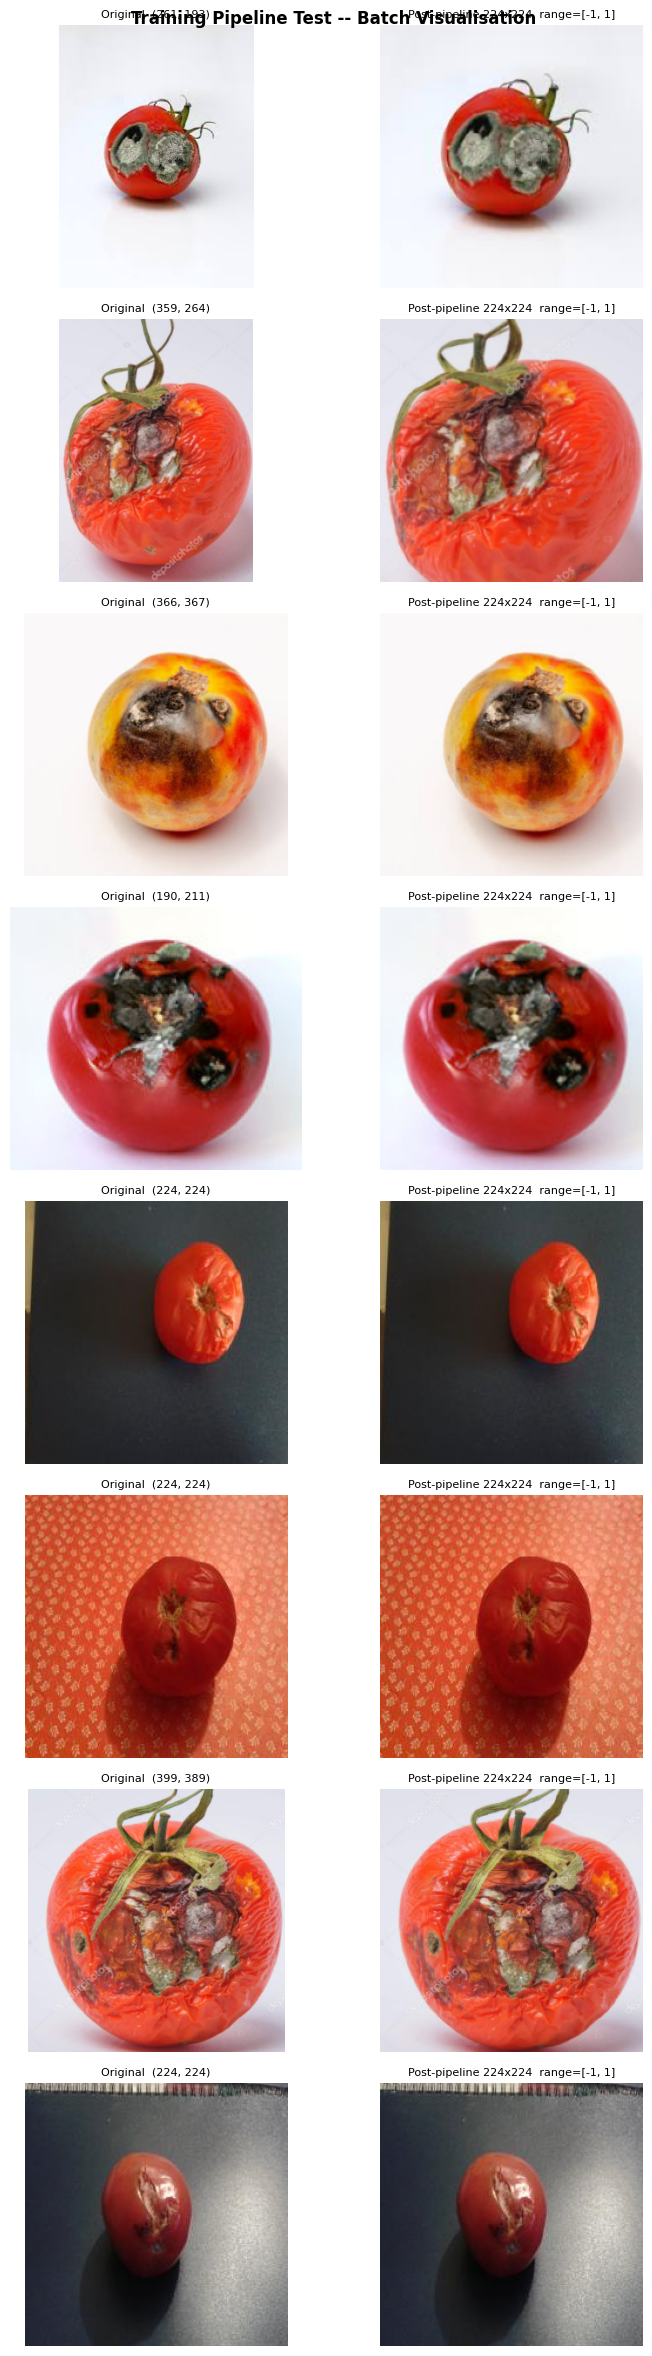

Batch image shape  : (64, 224, 224, 3)
dtype              : <dtype: 'float32'>
Min pixel value    : -1.000
Max pixel value    : 1.000
Expected range for MobileNetV2 normalisation: [-1, 1]

Building test model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Phase 1 test training (3 epochs)...
Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 111s 12s/step - accuracy: 0.1214 - auc: 0.6264 - loss: 3.3512 - val_accuracy: 0.3714 - val_auc: 0.8779 - val_loss: 2.4551
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5310 - auc: 0.9272 - loss: 2.0054 - val_accuracy: 0.6571 - val_auc: 0.9576 - val_loss: 1.5972
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.6976 - auc: 0.9757 - loss: 1.2291 - val_accuracy: 0.6857 - val_auc: 0.9733 - val_loss: 1.1223
Applying fine-tuning...
Phase 2 test training (2 epochs)...
Epoch 1/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.7786 - auc: 0.9875 - loss: 0.8624 - val_accuracy: 0.6857 - val_auc: 0.9758 - val_loss: 1.0404
Epoch 2/2
7/7 ━━━

In [10]:
from PIL import Image as PILImage

RUN_TEST = False

if not RUN_TEST:
    print('Test run skipped. Set RUN_TEST = True to execute.')
else:
    # -- Build subsets: 15 images per class from train, 5 from val and test ---
    _TEST_N_TRAIN = 15
    _TEST_N_EVAL  = 5

    def _subsample(samples, n_per_class):
        _by_class = {}
        for _fp, _li in samples:
            _by_class.setdefault(_li, []).append((_fp, _li))
        _result = []
        for _li, _items in _by_class.items():
            _result.extend(random.sample(_items, min(n_per_class, len(_items))))
        return _result

    _tr_sub  = _subsample(train_samples, _TEST_N_TRAIN)
    _val_sub = _subsample(val_samples,   _TEST_N_EVAL)
    _te_sub  = _subsample(test_samples,  _TEST_N_EVAL)

    print(f'Test subsets  train={len(_tr_sub)}  val={len(_val_sub)}  test={len(_te_sub)}')

    train_ds_test = build_dataset(_tr_sub,  training=True,  small_class_label_indices=small_class_index_set)
    val_ds_test   = build_dataset(_val_sub, training=False, small_class_label_indices=set())
    test_ds_test  = build_dataset(_te_sub,  training=False, small_class_label_indices=set())

    # -- Batch visualisation --------------------------------------------------
    # Take the first 8 samples (fixed, before shuffling) for side-by-side display.
    _n_viz       = min(8, len(_tr_sub))
    _viz_samples = _tr_sub[:_n_viz]

    # Load raw images from disk for the 'original' column.
    _raw_imgs = []
    for _fp, _li in _viz_samples:
        _img = PILImage.open(str(_fp)).convert('RGB')
        _raw_imgs.append(np.array(_img))

    # Get the same images through the pipeline (no shuffle, no aug for ordering).
    _viz_ds = build_dataset(_viz_samples, training=False, small_class_label_indices=set())
    _pp_batch_imgs, _pp_batch_labels = next(iter(_viz_ds))
    _pp_imgs   = _pp_batch_imgs.numpy()
    _pp_labels = np.argmax(_pp_batch_labels.numpy(), axis=1)

    def _denormalise_mobilenet(img):
        """Reverse MobileNetV2 preprocessing for display.

        MobileNetV2's preprocess_input maps [0, 255] -> [-1, 1] by:
            output = (input / 127.5) - 1
        The inverse is:
            input = (output + 1) * 127.5
        """
        _out = (img.copy().astype(np.float32) + 1.0) * 127.5
        return np.clip(_out, 0, 255).astype(np.uint8)

    _fig, _axes = plt.subplots(_n_viz, 2, figsize=(8, _n_viz * 3.0))
    _fig.suptitle('Training Pipeline Test -- Batch Visualisation', fontsize=12,
                  fontweight='bold')
    if _n_viz == 1:
        _axes = [_axes]

    for _row in range(_n_viz):
        _cls_name = class_names[_pp_labels[_row]]
        _axes[_row][0].imshow(_raw_imgs[_row])
        _axes[_row][0].set_title(f'Original  {_raw_imgs[_row].shape[:2]}', fontsize=8)
        _axes[_row][0].axis('off')
        _axes[_row][0].set_ylabel(_cls_name.replace('__', '\n'),
                                   rotation=0, labelpad=90, fontsize=7,
                                   ha='right', va='center')
        _axes[_row][1].imshow(_denormalise_mobilenet(_pp_imgs[_row]))
        _axes[_row][1].set_title('Post-pipeline 224x224  range=[-1, 1]', fontsize=8)
        _axes[_row][1].axis('off')

    plt.tight_layout()
    plt.show()

    # Confirm shape and normalised value range.
    _batch_full, _ = next(iter(train_ds_test))
    print(f'Batch image shape  : {_batch_full.shape}')
    print(f'dtype              : {_batch_full.dtype}')
    print(f'Min pixel value    : {_batch_full.numpy().min():.3f}')
    print(f'Max pixel value    : {_batch_full.numpy().max():.3f}')
    print('Expected range for MobileNetV2 normalisation: [-1, 1]')

    # -- Phase 1 training: 3 epochs, no early stopping, no file saves ---------
    # Uses the exact same callback structure as the full pipeline (Sections 9
    # and 10), minus callbacks that write files. The PeriodicWeightCheckpoint
    # is included but points to a temp directory that is deleted at the end.
    import tempfile, shutil
    _tmp_dir = Path(tempfile.mkdtemp())

    print()
    print('Building test model...')
    _test_model = build_model(
        learning_rate_phase1=1e-3,
        dropout_rate=0.3,
        dense_units=256,
        num_unfreeze=20
    )

    _test_periodic_cb = PeriodicWeightCheckpoint(
        save_every=PERIODIC_CKPT_EVERY,
        save_dir=_tmp_dir,
        phase_key='phase1'
    )

    print('Phase 1 test training (3 epochs)...')
    _hist1 = _test_model.fit(
        train_ds_test,
        validation_data=val_ds_test,
        epochs=3,
        callbacks=[_test_periodic_cb],
        verbose=1
    )

    # -- Phase 2 fine-tuning: 2 epochs, no early stopping, no file saves ------
    print('Applying fine-tuning...')
    _test_model = apply_fine_tuning(_test_model, num_unfreeze=20)

    _test_periodic_cb2 = PeriodicWeightCheckpoint(
        save_every=PERIODIC_CKPT_EVERY,
        save_dir=_tmp_dir,
        phase_key='phase2'
    )

    print('Phase 2 test training (2 epochs)...')
    _hist2 = _test_model.fit(
        train_ds_test,
        validation_data=val_ds_test,
        epochs=2,
        callbacks=[_test_periodic_cb2],
        verbose=1
    )

    print()
    print(f'Phase 1 final train_loss : {_hist1.history["loss"][-1]:.4f}')
    print(f'Phase 1 final val_loss   : {_hist1.history["val_loss"][-1]:.4f}')
    print(f'Phase 2 final train_loss : {_hist2.history["loss"][-1]:.4f}')
    print(f'Phase 2 final val_loss   : {_hist2.history["val_loss"][-1]:.4f}')

    shutil.rmtree(_tmp_dir)
    del _test_model
    print()
    print('Test run complete. No files saved. Safe to proceed with the full pipeline.')

## Section 8   Keras Tuner Hyperparameter Search

Keras Tuner with the Hyperband algorithm searches the following hyperparameter space on a 20% random subset of training data (`TUNER_SUBSET_FRAC`) to reduce wall-clock time. The objective is `val_auc` (maximised). Results are persisted to `TUNER_DIR` with `overwrite=False` so the search can be resumed if the session is interrupted. Best hyperparameters are saved to `best_hyperparameters.json` for use in Sections 9 and 10.

In [11]:
if SKIP_ALL or past_stage(CURRENT_STAGE, 'tuner_complete'):
    print('Section 8 skipped: hyperparameter search already complete.')
    _hp_path = CHECKPOINT_DIR / 'best_hyperparameters.json'
    if _hp_path.exists():
        with open(_hp_path, 'r', encoding='utf-8') as fh:
            best_hp = json.load(fh)
        print('Best hyperparameters loaded from disk:')
        for _k, _v in best_hp.items():
            print(f'  {_k}: {_v}')
else:
    # Re-seed before sampling so the same 20% subset is drawn on every re-run.
    random.seed(RANDOM_SEED)
    _n_tuner = int(len(train_samples) * TUNER_SUBSET_FRAC)
    _tuner_samples = random.sample(train_samples, _n_tuner)

    train_ds_tuner = build_dataset(_tuner_samples, training=True,  small_class_label_indices=small_class_index_set)
    val_ds_tuner   = build_dataset(val_samples,    training=False, small_class_label_indices=set())

    print(f'Tuner training subset : {len(_tuner_samples):,} samples')
    print(f'Tuner val set         : {len(val_samples):,} samples')

    # -- Define the tunable model builder -------------------------------------
    def build_tunable_model(hp):
        _lr       = hp.Choice('learning_rate_phase1', values=[1e-3, 5e-4, 1e-4])
        _dropout  = hp.Choice('dropout_rate',         values=[0.2, 0.3, 0.4])
        _dense    = hp.Choice('dense_units',          values=[128, 256, 512])
        _unfreeze = hp.Choice('num_unfreeze',         values=[10, 20, 30])
        return build_model(_lr, _dropout, _dense, _unfreeze)

    # -- Instantiate Hyperband tuner ------------------------------------------
    tuner = keras_tuner.Hyperband(
        hypermodel=build_tunable_model,
        objective=keras_tuner.Objective('val_auc', direction='max'),
        max_epochs=TUNER_MAX_EPOCHS,
        factor=TUNER_FACTOR,
        directory=str(TUNER_DIR),
        project_name='mobilenetv2_brfn',
        overwrite=False   # persist results to TUNER_DIR; allows resuming an interrupted search
    )

    tuner.search_space_summary()

    # -- Run search -----------------------------------------------------------
    tuner.search(
        train_ds_tuner,
        validation_data=val_ds_tuner,
        epochs=TUNER_MAX_EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_auc', patience=5, mode='max'
            )
        ]
    )

    # -- Retrieve and save best hyperparameters --------------------------------
    _best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_hp = {
        'learning_rate_phase1': float(_best_hps.get('learning_rate_phase1')),
        'dropout_rate'        : float(_best_hps.get('dropout_rate')),
        'dense_units'         : int(_best_hps.get('dense_units')),
        'num_unfreeze'        : int(_best_hps.get('num_unfreeze')),
    }

    print()
    print('Best hyperparameters found:')
    for _k, _v in best_hp.items():
        print(f'  {_k}: {_v}')

    _hp_path = CHECKPOINT_DIR / 'best_hyperparameters.json'
    with open(_hp_path, 'w', encoding='utf-8') as fh:
        json.dump(best_hp, fh, indent=2)
    print(f'Saved to {_hp_path}')

    save_checkpoint('tuner_complete', best_hp)
    CURRENT_STAGE = 'tuner_complete'

Trial 30 Complete [00h 03m 22s]
val_auc: 0.9975646138191223

Best val_auc So Far: 0.9976958632469177
Total elapsed time: 00h 56m 46s

Best hyperparameters found:
  learning_rate_phase1: 0.001
  dropout_rate: 0.3
  dense_units: 128
  num_unfreeze: 20
Saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/best_hyperparameters.json
Checkpoint saved  stage="tuner_complete"  timestamp=2026-04-13T15:43:53


## Section 9   Phase 1 Training (Head Only)

Phase 1 trains only the classification head with the MobileNetV2 backbone frozen. Training the head first gives the randomly initialised weights a sensible configuration before any backbone layers are modified, preventing large gradient signals from corrupting pre-trained representations.

Three callbacks: `EarlyStopping` (monitor `val_loss`, patience `PHASE1_PATIENCE`, restore best weights), `ModelCheckpoint` (save best weights by `val_auc`), and `ReduceLROnPlateau` (factor 0.5, patience 5, min 1e-6). Class weights are applied via `model.fit`'s `class_weight` argument. If a periodic checkpoint exists, weights are loaded and `initial_epoch` is set for mid-phase resumption.

Hyperparameters for Phase 1:
  learning_rate_phase1: 0.001
  dropout_rate: 0.3
  dense_units: 128
  num_unfreeze: 20


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,564 (9.25 MB)

 Trainable params: 167,580 (654.61 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting Phase 1 from epoch 0.

Starting Phase 1 training...
Epoch 1/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5716 - auc: 0.9246 - loss: 1.4939
Epoch 1: val_auc improved from None to 0.99603, saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/keras_weights/phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/keras_weights/phase1_best.weights.h5
321/321 ━━━━━━━━━━━━━━━━━━━━ 2108s 7s/step - accuracy: 0.7271 - auc: 0.9792 - loss: 0.8995 - val_accuracy: 0.8912 - val_auc: 0.9960 - val_loss: 0.3487 - learning_rate: 0.0010
Epoch 2/50
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8596 - auc: 0.9930 - loss: 0.4239
Epoch 2: val_auc improved from 0.99603 to 0.99728, saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/keras_weights/phase1_best.weights.h5

Epoch 2: finished saving model to /co

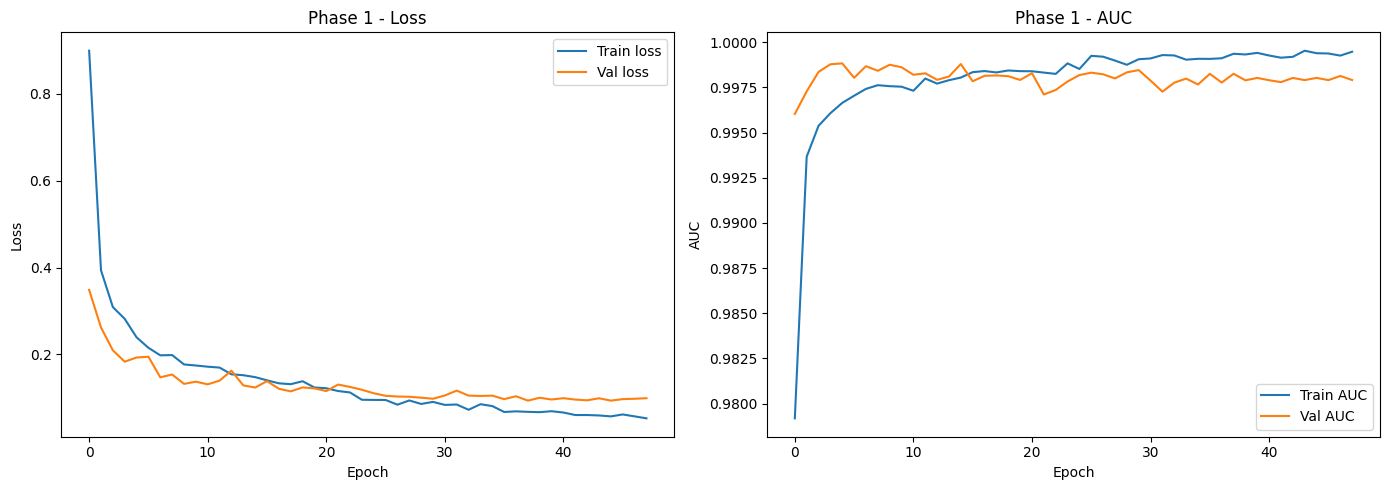

Training curves saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/phase1_training_curves.png
Phase 1 best val_loss : 0.0937
Phase 1 best val_auc  : 0.9988
Checkpoint saved  stage="phase1_complete"  timestamp=2026-04-13T16:48:08


In [12]:
if SKIP_ALL or past_stage(CURRENT_STAGE, 'phase1_complete'):
    print('Section 9 skipped: Phase 1 training already complete.')
else:
    # Load best hyperparameters from disk.
    _hp_path = CHECKPOINT_DIR / 'best_hyperparameters.json'
    with open(_hp_path, 'r', encoding='utf-8') as fh:
        best_hp = json.load(fh)
    print('Hyperparameters for Phase 1:')
    for _k, _v in best_hp.items():
        print(f'  {_k}: {_v}')

    # Build the full model with best hyperparameters.
    model = build_model(
        learning_rate_phase1=best_hp['learning_rate_phase1'],
        dropout_rate=best_hp['dropout_rate'],
        dense_units=best_hp['dense_units'],
        num_unfreeze=best_hp['num_unfreeze']
    )
    model.summary()

    # -- Check for a periodic checkpoint to resume from ----------------------
    _p1_resume_epoch = 0
    _ckpt_meta = (load_checkpoint() or {}).get('metadata', {})
    _p1_periodic_weights = _ckpt_meta.get('phase1_last_periodic_weights')
    _p1_periodic_epoch   = _ckpt_meta.get('phase1_last_periodic_epoch', 0)

    if _p1_periodic_weights and Path(_p1_periodic_weights).exists():
        model.load_weights(_p1_periodic_weights)
        _p1_resume_epoch = int(_p1_periodic_epoch)
        print(f'Resuming Phase 1 from epoch {_p1_resume_epoch} '
              f'(loaded weights from {_p1_periodic_weights})')
    else:
        # No periodic checkpoint -- check for the best-weights file from a
        # previous full run attempt, which may exist if training completed
        # at least one improvement before being interrupted.
        _p1_weights = KERAS_CKPT_DIR / 'phase1_best.weights.h5'
        if _p1_weights.exists():
            model.load_weights(str(_p1_weights))
            print(f'Phase 1 best weights loaded from {_p1_weights}')
        else:
            print('Starting Phase 1 from epoch 0.')

    # Re-build train and val datasets from the full split lists.
    train_ds = build_dataset(train_samples, training=True,  small_class_label_indices=small_class_index_set)
    val_ds   = build_dataset(val_samples,   training=False, small_class_label_indices=set())

    # Define Phase 1 callbacks.
    _p1_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PHASE1_PATIENCE,
            restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(KERAS_CKPT_DIR / 'phase1_best.weights.h5'),
            monitor='val_auc',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        PeriodicWeightCheckpoint(
            save_every=PERIODIC_CKPT_EVERY,
            save_dir=PERIODIC_CKPT_DIR,
            phase_key='phase1'
        ),
    ]

    print()
    print('Starting Phase 1 training...')
    history_p1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=PHASE1_EPOCHS,
        initial_epoch=_p1_resume_epoch,  # Keras skips epochs before this value; 0 for a fresh start
        class_weight=class_weights,
        callbacks=_p1_callbacks
    )

    # Plot and save training curves.
    _p1_curve_path = CHECKPOINT_DIR / 'phase1_training_curves.png'
    _plot_history(history_p1, _p1_curve_path, 'Phase 1')

    _best_val_loss = min(history_p1.history['val_loss'])
    _best_val_auc  = max(history_p1.history['val_auc'])
    print(f'Phase 1 best val_loss : {_best_val_loss:.4f}')
    print(f'Phase 1 best val_auc  : {_best_val_auc:.4f}')

    save_checkpoint('phase1_complete', {
        'best_val_loss': round(float(_best_val_loss), 4),
        'best_val_auc' : round(float(_best_val_auc), 4),
    })
    CURRENT_STAGE = 'phase1_complete'

## Section 10   Phase 2 Fine-Tuning

Phase 2 unfreezes the top `num_unfreeze` backbone layers and continues training at `PHASE2_LR = 1e-5` — two orders of magnitude lower than Phase 1. The low learning rate is critical: higher rates would overwrite ImageNet-learned features too aggressively. BatchNormalization layers remain frozen throughout to preserve their running statistics.

Phase 1 best weights are loaded before fine-tuning begins so Phase 2 starts from the optimal Phase 1 configuration rather than the last epoch state. The final model is saved with `model.save` to `MODEL_SAVE_PATH` in HDF5 format.

Phase 1 best weights loaded from /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/keras_weights/phase1_best.weights.h5
Trainable parameters : 1,362,460 / 2,425,564
Starting Phase 2 from epoch 0.

Starting Phase 2 fine-tuning...
Epoch 1/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.9286 - auc: 0.9973 - loss: 0.2060
Epoch 1: val_auc improved from None to 0.99852, saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/keras_weights/phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/keras_weights/phase2_best.weights.h5
321/321 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.9295 - auc: 0.9975 - loss: 0.1902 - val_accuracy: 0.9492 - val_auc: 0.9985 - val_loss: 0.1564 - learning_rate: 1.0000e-05
Epoch 2/30
320/321 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9382 - auc: 0.9976 - loss: 0.1779
Epoch 2: val_auc i

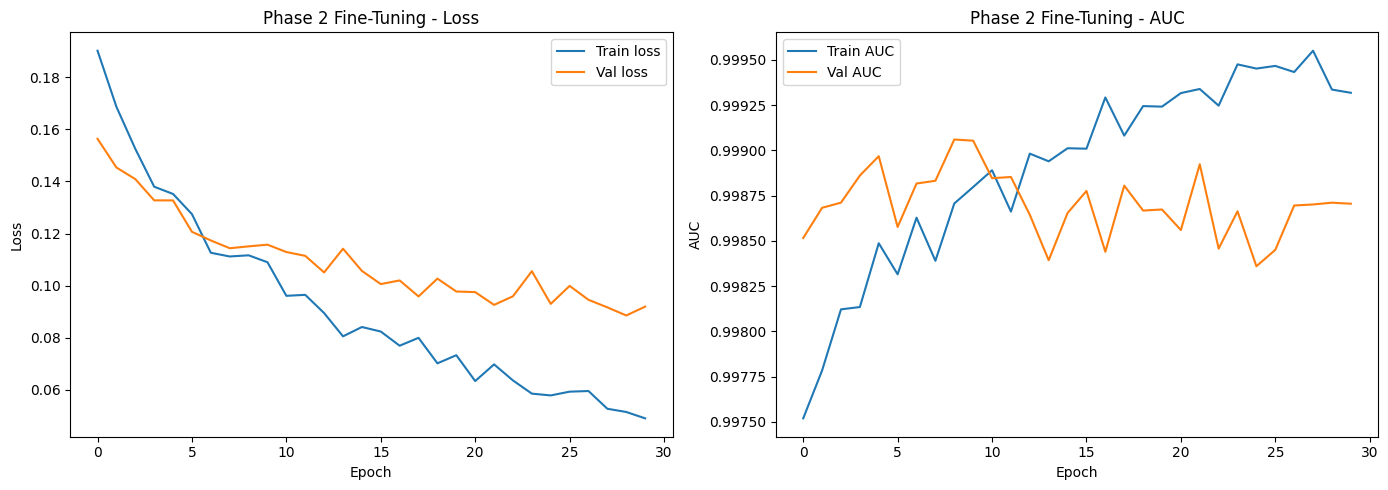

Training curves saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/phase2_training_curves.png
Phase 2 best val_loss : 0.0886
Phase 2 best val_auc  : 0.9991
Final model saved to /content/drive/MyDrive/Advanced AI/advanced-ai/models/mobilenetv2_brfn.h5
Checkpoint saved  stage="phase2_complete"  timestamp=2026-04-13T17:11:31


In [13]:
if SKIP_ALL or past_stage(CURRENT_STAGE, 'phase2_complete'):
    print('Section 10 skipped: Phase 2 fine-tuning already complete.')
else:
    # Load best hyperparameters.
    _hp_path = CHECKPOINT_DIR / 'best_hyperparameters.json'
    with open(_hp_path, 'r', encoding='utf-8') as fh:
        best_hp = json.load(fh)

    # Rebuild model and load Phase 1 best weights.
    model = build_model(
        learning_rate_phase1=best_hp['learning_rate_phase1'],
        dropout_rate=best_hp['dropout_rate'],
        dense_units=best_hp['dense_units'],
        num_unfreeze=best_hp['num_unfreeze']
    )
    _p1_weights = KERAS_CKPT_DIR / 'phase1_best.weights.h5'
    if _p1_weights.exists():
        model.load_weights(str(_p1_weights))
        print(f'Phase 1 best weights loaded from {_p1_weights}')
    else:
        print('Phase 1 weight file not found. Proceeding from current model state.')

    # Apply fine-tuning: unfreeze top layers and recompile at low learning rate.
    model = apply_fine_tuning(model, num_unfreeze=best_hp['num_unfreeze'])

    _trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    _total     = sum(tf.size(w).numpy() for w in model.weights)
    print(f'Trainable parameters : {_trainable:,} / {_total:,}')

    # -- Check for a periodic checkpoint to resume from ----------------------
    _p2_resume_epoch = 0
    _ckpt_meta = (load_checkpoint() or {}).get('metadata', {})
    _p2_periodic_weights = _ckpt_meta.get('phase2_last_periodic_weights')
    _p2_periodic_epoch   = _ckpt_meta.get('phase2_last_periodic_epoch', 0)

    if _p2_periodic_weights and Path(_p2_periodic_weights).exists():
        model.load_weights(_p2_periodic_weights)
        _p2_resume_epoch = int(_p2_periodic_epoch)
        print(f'Resuming Phase 2 from epoch {_p2_resume_epoch} '
              f'(loaded weights from {_p2_periodic_weights})')
    else:
        print('Starting Phase 2 from epoch 0.')

    # Re-build datasets.
    train_ds = build_dataset(train_samples, training=True,  small_class_label_indices=small_class_index_set)
    val_ds   = build_dataset(val_samples,   training=False, small_class_label_indices=set())

    # Define Phase 2 callbacks.
    _p2_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PHASE2_PATIENCE,
            restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(KERAS_CKPT_DIR / 'phase2_best.weights.h5'),
            monitor='val_auc',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        PeriodicWeightCheckpoint(
            save_every=PERIODIC_CKPT_EVERY,
            save_dir=PERIODIC_CKPT_DIR,
            phase_key='phase2'
        ),
    ]

    print()
    print('Starting Phase 2 fine-tuning...')
    history_p2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=PHASE2_EPOCHS,
        initial_epoch=_p2_resume_epoch,  # Keras skips epochs before this value; 0 for a fresh start
        class_weight=class_weights,
        callbacks=_p2_callbacks
    )

    # Plot and save fine-tuning curves.
    _p2_curve_path = CHECKPOINT_DIR / 'phase2_training_curves.png'
    _plot_history(history_p2, _p2_curve_path, 'Phase 2 Fine-Tuning')

    _best_val_loss = min(history_p2.history['val_loss'])
    _best_val_auc  = max(history_p2.history['val_auc'])
    print(f'Phase 2 best val_loss : {_best_val_loss:.4f}')
    print(f'Phase 2 best val_auc  : {_best_val_auc:.4f}')

    # Save the final model.
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    model.save(str(MODEL_SAVE_PATH))
    print(f'Final model saved to {MODEL_SAVE_PATH}')

    save_checkpoint('phase2_complete', {
        'best_val_loss'  : round(float(_best_val_loss), 4),
        'best_val_auc'   : round(float(_best_val_auc), 4),
        'model_save_path': str(MODEL_SAVE_PATH),
    })
    CURRENT_STAGE = 'phase2_complete'

## Section 11   Evaluation on the Test Set

The test set was held out entirely during training and hyperparameter search. This section evaluates the saved model and produces four visualisations: a 28×28 confusion matrix heatmap, a per-class F1 bar chart (sorted descending, coloured by produce type), a prediction confidence distribution comparing correct vs incorrect predictions, and ROC curves (one-vs-rest per class plus a macro-average curve). All metrics are saved to `evaluation_metrics.json`.

Loading model from /content/drive/MyDrive/Advanced AI/advanced-ai/models/mobilenetv2_brfn.h5...
Model loaded.
69/69 ━━━━━━━━━━━━━━━━━━━━ 472s 7s/step

Classification report:
                      precision    recall  f1-score   support

      Apple__Healthy       0.95      0.99      0.97       365
       Apple__Rotten       0.98      0.94      0.96       439
     Banana__Healthy       0.99      1.00      1.00       300
      Banana__Rotten       1.00      0.99      0.99       420
 Bellpepper__Healthy       0.95      0.98      0.96        92
  Bellpepper__Rotten       0.90      0.84      0.87        89
     Carrot__Healthy       0.97      0.99      0.98        93
      Carrot__Rotten       0.95      0.94      0.95        87
   Cucumber__Healthy       0.96      0.99      0.97        91
    Cucumber__Rotten       0.98      1.00      0.99        89
      Grape__Healthy       1.00      1.00      1.00        30
       Grape__Rotten       0.93      0.93      0.93        30
      Guava__Health

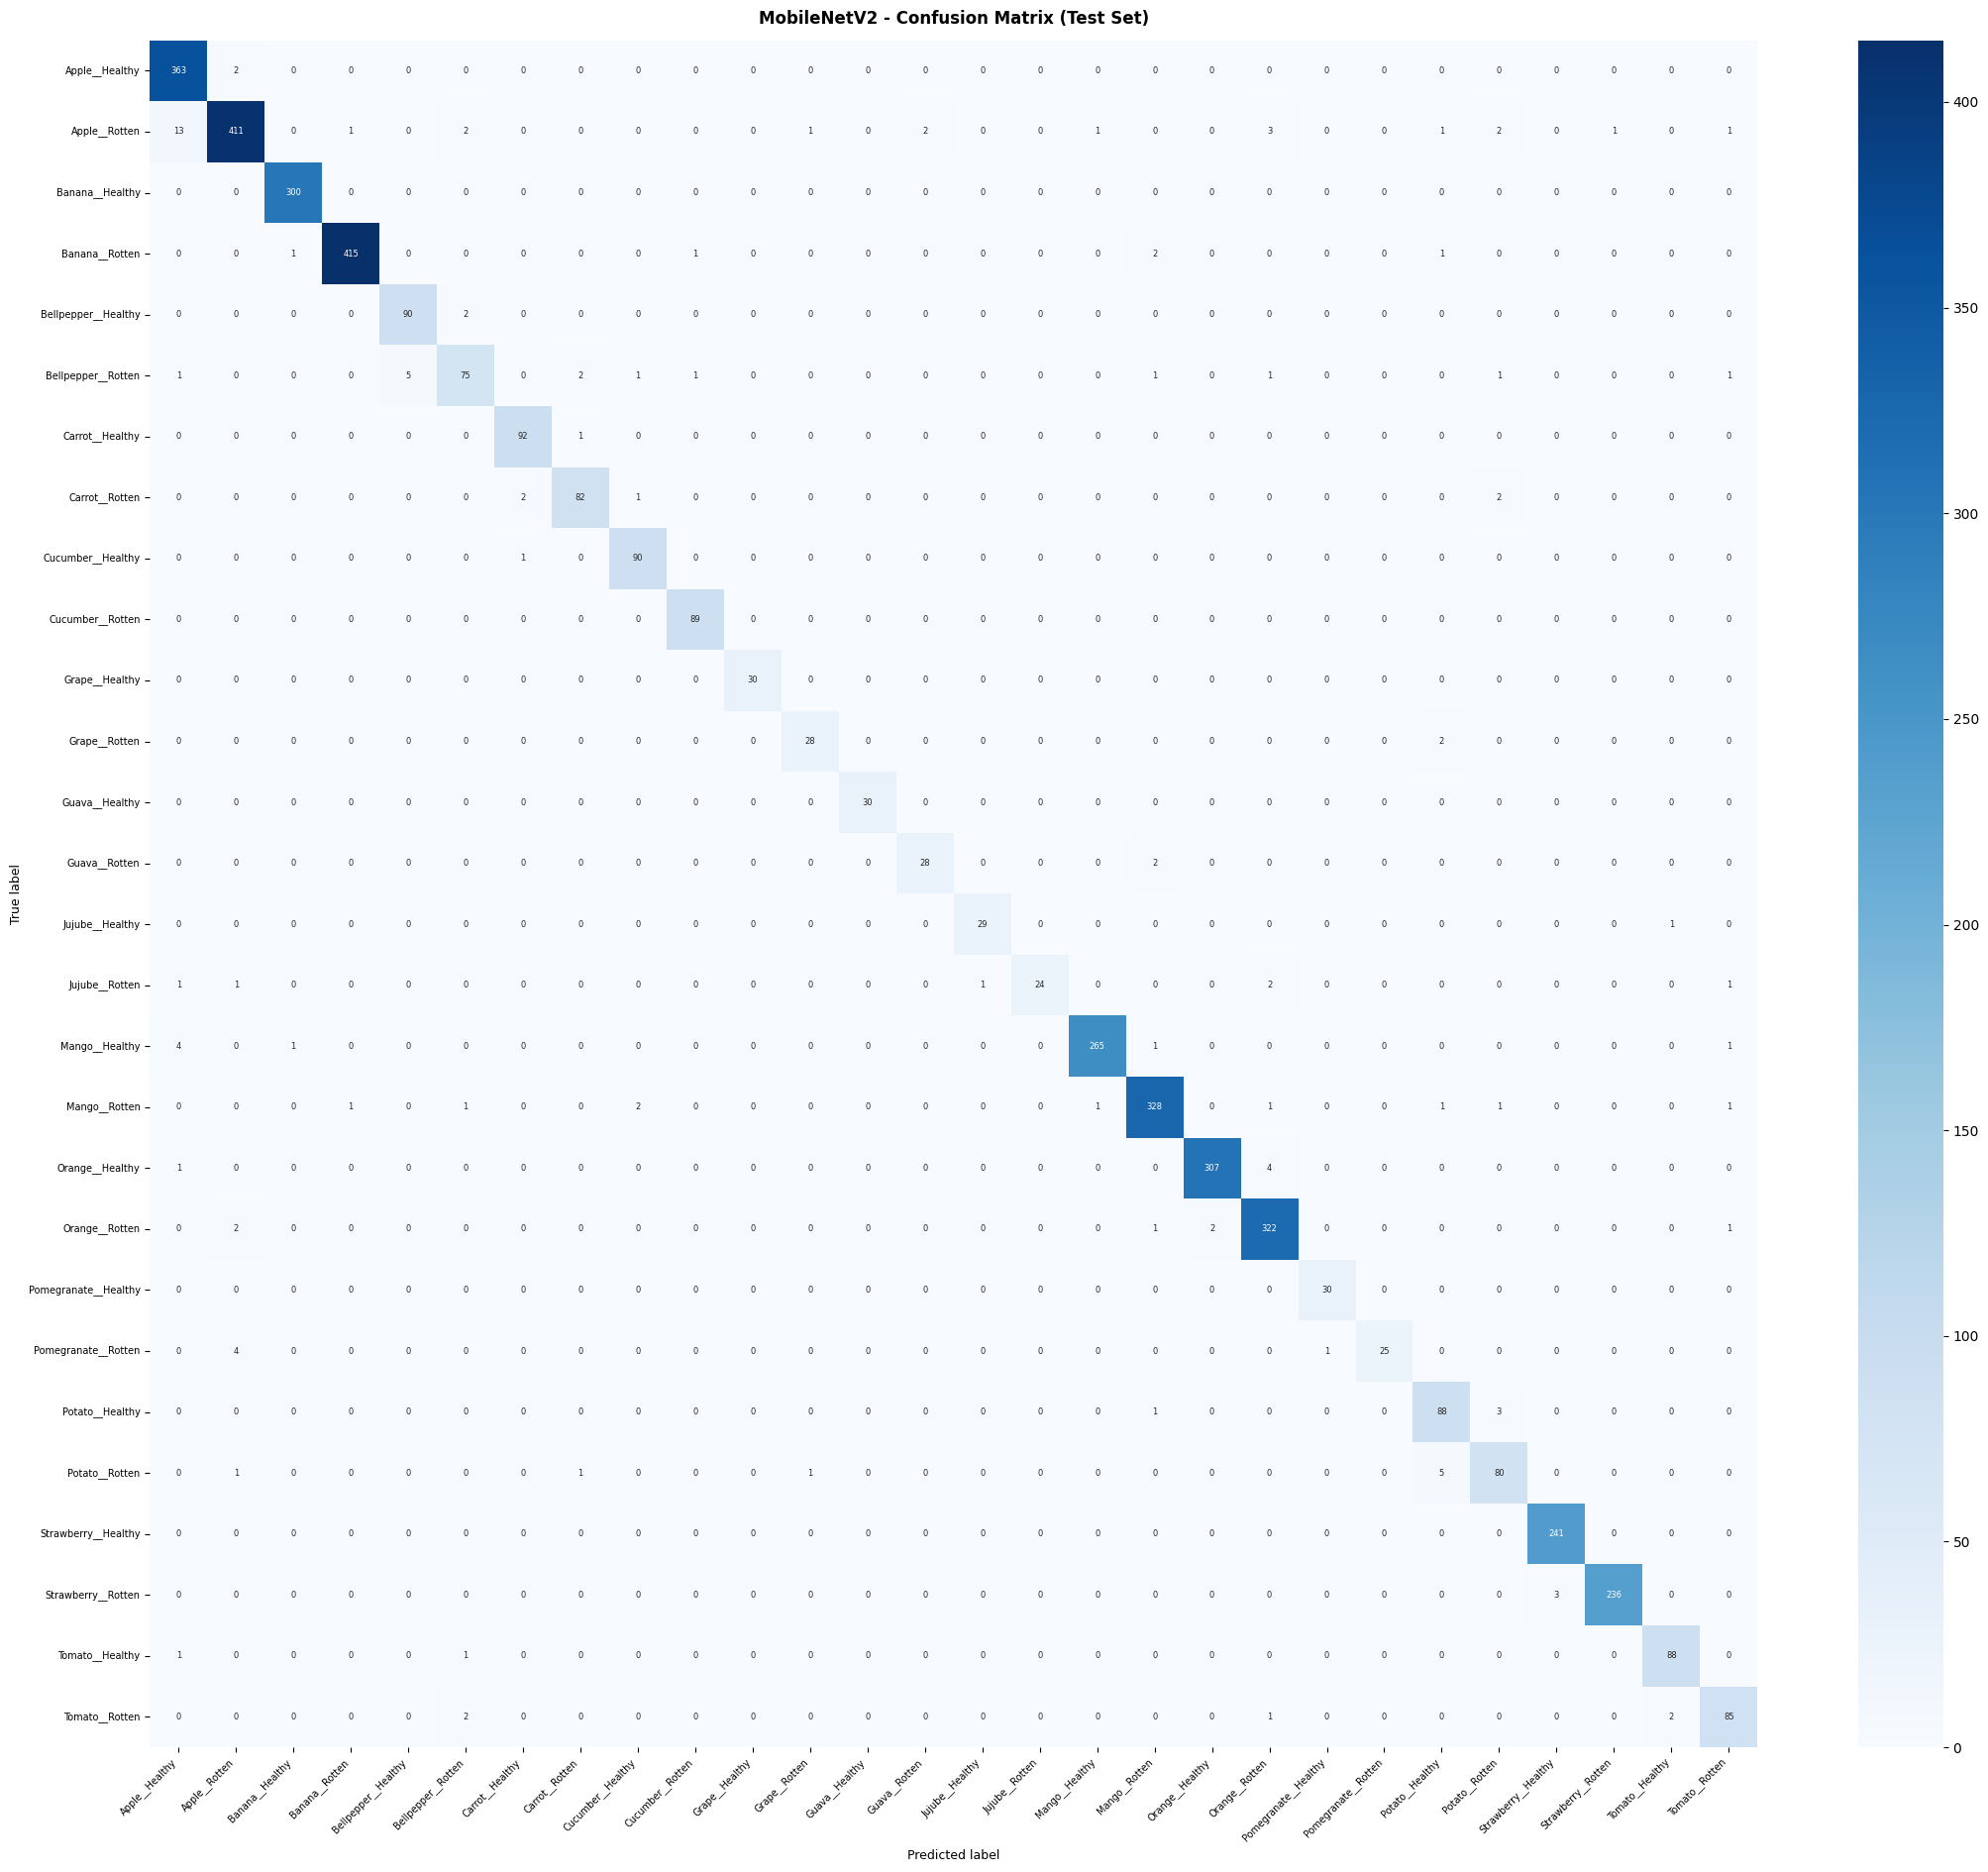

Confusion matrix saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/confusion_matrix.png


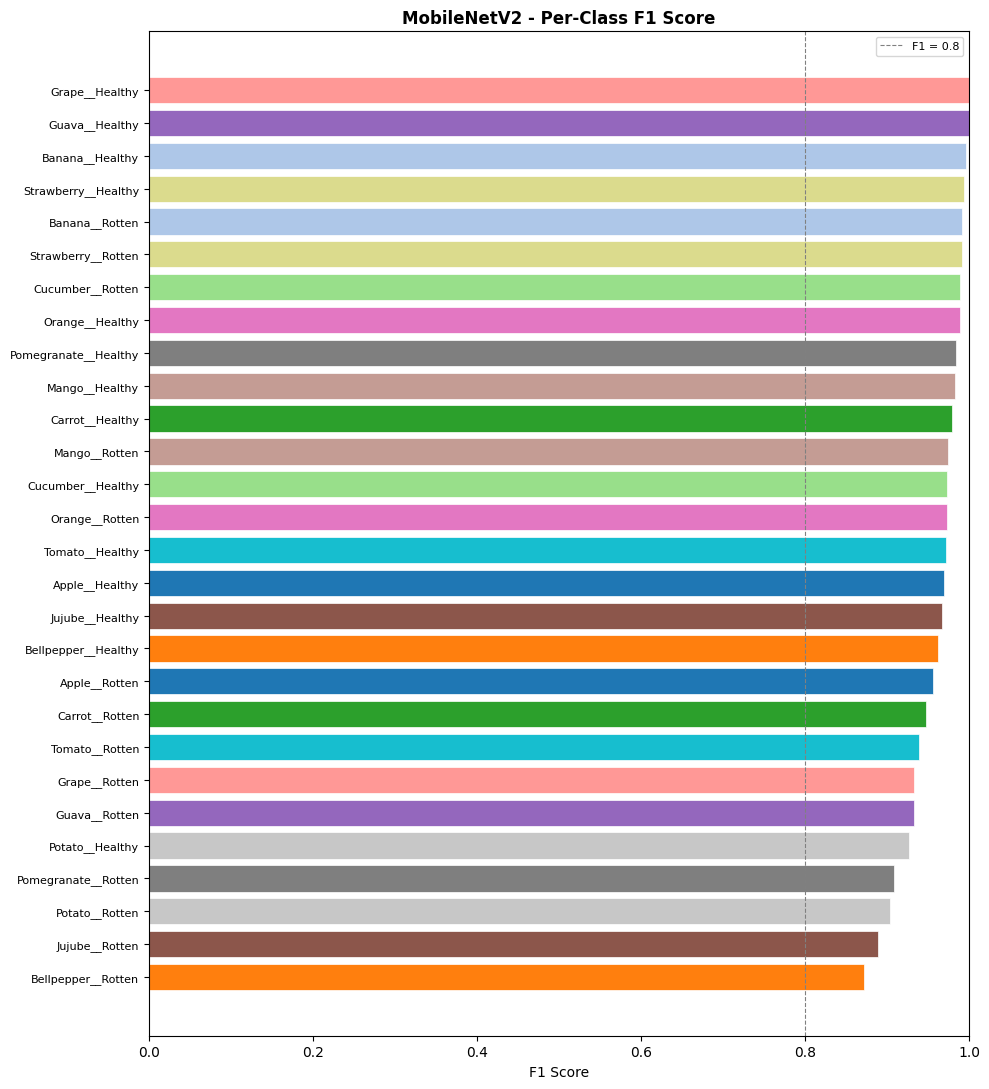

Per-class F1 chart saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/per_class_f1.png


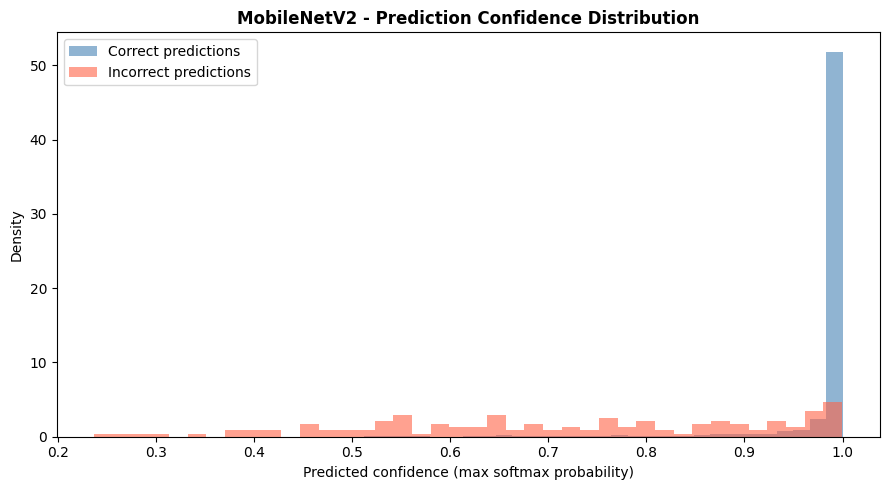

Confidence distribution saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/confidence_distribution.png


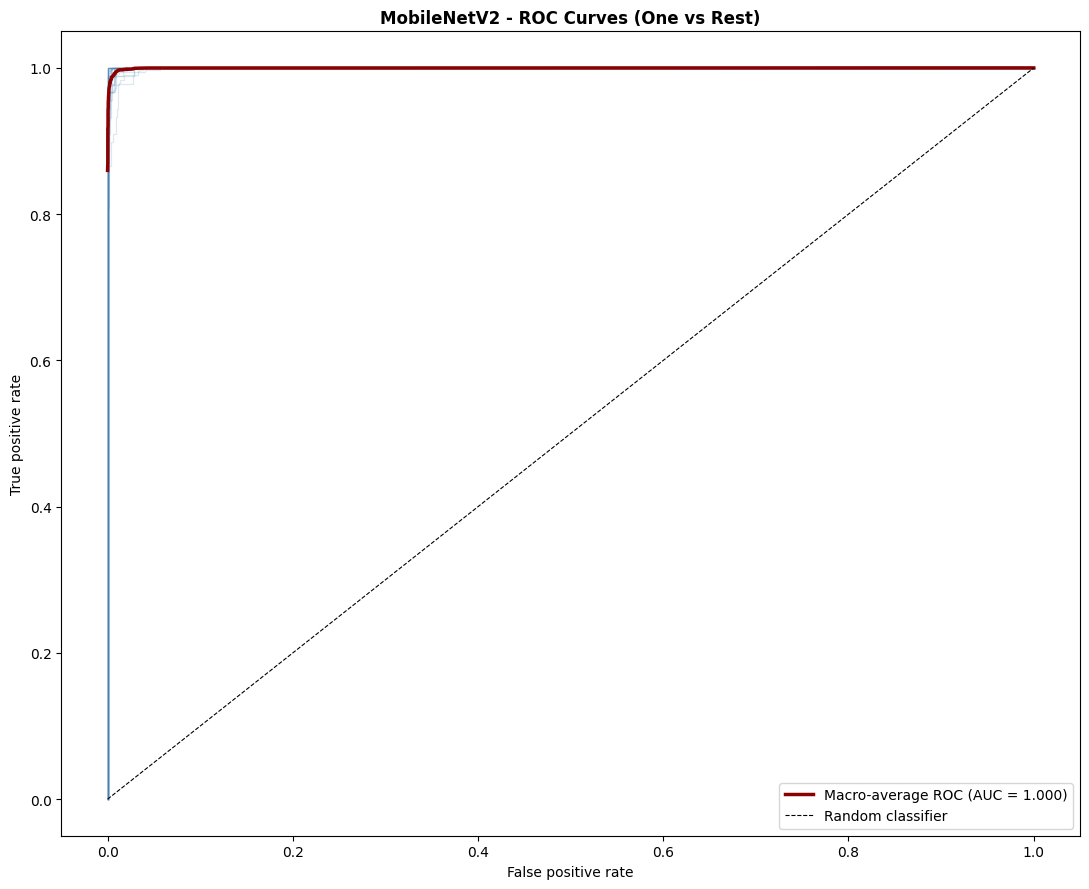

ROC curves saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/roc_curves.png
Evaluation metrics saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/checkpoints/mobilenetv2/evaluation_metrics.json
Checkpoint saved  stage="evaluation_complete"  timestamp=2026-04-13T17:19:53


In [14]:
if SKIP_ALL:
    print('Section 11 skipped: evaluation already complete.')
else:
    # -- Load the saved model -------------------------------------------------
    print(f'Loading model from {MODEL_SAVE_PATH}...')
    _eval_model = keras.models.load_model(str(MODEL_SAVE_PATH), compile=False)
    print('Model loaded.')

    # -- Build test dataset and run predictions --------------------------------
    test_ds = build_dataset(test_samples, training=False, small_class_label_indices=set())

    y_pred_probs = _eval_model.predict(test_ds, verbose=1)
    y_pred_idx   = np.argmax(y_pred_probs, axis=1)

    # Reconstruct true integer labels from the test dataset.
    y_true_onehot = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
    y_true_idx    = np.argmax(y_true_onehot, axis=1)

    # -- Classification report -----------------------------------------------
    print()
    print('Classification report:')
    _report_str  = classification_report(
        y_true_idx, y_pred_idx, target_names=class_names
    )
    _report_dict = classification_report(
        y_true_idx, y_pred_idx, target_names=class_names, output_dict=True
    )
    print(_report_str)

    _accuracy       = _report_dict['accuracy']
    _macro_f1       = _report_dict['macro avg']['f1-score']
    _macro_prec     = _report_dict['macro avg']['precision']
    _macro_recall   = _report_dict['macro avg']['recall']
    _per_class_f1   = {cls: _report_dict[cls]['f1-score'] for cls in class_names}

    # Macro AUC-ROC (one-vs-rest).
    _y_true_bin = label_binarize(y_true_idx, classes=range(num_classes))
    _macro_auc  = roc_auc_score(_y_true_bin, y_pred_probs,
                                multi_class='ovr', average='macro')

    print(f'Accuracy        : {_accuracy:.4f}')
    print(f'Macro F1        : {_macro_f1:.4f}')
    print(f'Macro Precision : {_macro_prec:.4f}')
    print(f'Macro Recall    : {_macro_recall:.4f}')
    print(f'Macro AUC-ROC   : {_macro_auc:.4f}')

    # -- Confusion matrix heatmap ---------------------------------------------
    _cm = confusion_matrix(y_true_idx, y_pred_idx)
    _cm_path = CHECKPOINT_DIR / 'confusion_matrix.png'
    _fig, _ax = plt.subplots(figsize=(22, 19))
    sns.heatmap(
        _cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=_ax, annot_kws={'size': 6}
    )
    _ax.set_xticklabels(_ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    _ax.set_yticklabels(_ax.get_yticklabels(), rotation=0, fontsize=7)
    _ax.set_xlabel('Predicted label', fontsize=9)
    _ax.set_ylabel('True label', fontsize=9)
    _ax.set_title('MobileNetV2 - Confusion Matrix (Test Set)', fontsize=12,
                  fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(str(_cm_path), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved to {_cm_path}')

    # -- Per-class F1 bar chart -----------------------------------------------
    _produce_types = sorted({c.split('__')[0] for c in class_names})
    _cmap14        = plt.cm.tab20
    _p_colour      = {p: _cmap14(i / len(_produce_types))
                      for i, p in enumerate(_produce_types)}

    _sorted_f1 = sorted(_per_class_f1.items(), key=lambda x: x[1], reverse=True)
    _bar_cls   = [x[0] for x in _sorted_f1]
    _bar_vals  = [x[1] for x in _sorted_f1]
    _bar_cols  = [_p_colour[c.split('__')[0]] for c in _bar_cls]

    _f1_path = CHECKPOINT_DIR / 'per_class_f1.png'
    _fig, _ax = plt.subplots(figsize=(10, 11))
    _ax.barh(_bar_cls, _bar_vals, color=_bar_cols, edgecolor='white', linewidth=0.5)
    _ax.set_xlabel('F1 Score')
    _ax.set_xlim(0, 1)
    _ax.invert_yaxis()
    _ax.set_title('MobileNetV2 - Per-Class F1 Score', fontsize=12,
                  fontweight='bold')
    _ax.axvline(0.8, color='gray', linestyle='--', linewidth=0.8, label='F1 = 0.8')
    _ax.legend(fontsize=8)
    _ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig(str(_f1_path), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Per-class F1 chart saved to {_f1_path}')

    # -- Confidence distribution histogram ------------------------------------
    _confidence   = np.max(y_pred_probs, axis=1)
    _correct_mask = (y_pred_idx == y_true_idx)
    _conf_correct = _confidence[_correct_mask]
    _conf_wrong   = _confidence[~_correct_mask]

    _conf_path = CHECKPOINT_DIR / 'confidence_distribution.png'
    _fig, _ax  = plt.subplots(figsize=(9, 5))
    _ax.hist(_conf_correct, bins=40, alpha=0.6, label='Correct predictions',
             color='steelblue', density=True)
    _ax.hist(_conf_wrong, bins=40, alpha=0.6, label='Incorrect predictions',
             color='tomato', density=True)
    _ax.set_xlabel('Predicted confidence (max softmax probability)')
    _ax.set_ylabel('Density')
    _ax.set_title('MobileNetV2 - Prediction Confidence Distribution',
                  fontsize=12, fontweight='bold')
    _ax.legend()
    plt.tight_layout()
    plt.savefig(str(_conf_path), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Confidence distribution saved to {_conf_path}')

    # -- ROC curves (one-vs-rest per class + macro average) -------------------
    _fpr, _tpr, _roc_auc = {}, {}, {}
    for _i in range(num_classes):
        _fpr[_i], _tpr[_i], _ = roc_curve(_y_true_bin[:, _i], y_pred_probs[:, _i])
        _roc_auc[_i] = sklearn_auc(_fpr[_i], _tpr[_i])

    # Compute macro-average ROC curve by interpolation.
    _all_fpr   = np.unique(np.concatenate([_fpr[_i] for _i in range(num_classes)]))  # common FPR grid across all classes
    _mean_tpr  = np.zeros_like(_all_fpr)
    for _i in range(num_classes):
        _mean_tpr += np.interp(_all_fpr, _fpr[_i], _tpr[_i])  # interpolate each class's TPR at the shared FPR points
    _mean_tpr  /= num_classes  # average gives the macro-average ROC curve
    _macro_roc_auc_plot = sklearn_auc(_all_fpr, _mean_tpr)

    _roc_path = CHECKPOINT_DIR / 'roc_curves.png'
    _fig, _ax = plt.subplots(figsize=(11, 9))
    for _i in range(num_classes):
        _ax.plot(_fpr[_i], _tpr[_i], alpha=0.18, linewidth=0.9,
                 color='steelblue')
    _ax.plot(_all_fpr, _mean_tpr, color='darkred', linewidth=2.5,
             label=f'Macro-average ROC (AUC = {_macro_roc_auc_plot:.3f})')
    _ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
    _ax.set_xlabel('False positive rate')
    _ax.set_ylabel('True positive rate')
    _ax.set_title('MobileNetV2 - ROC Curves (One vs Rest)',
                  fontsize=12, fontweight='bold')
    _ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str(_roc_path), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'ROC curves saved to {_roc_path}')

    # -- Save evaluation metrics ----------------------------------------------
    _eval_metrics = {
        'accuracy'       : round(float(_accuracy),     4),
        'macro_f1'       : round(float(_macro_f1),     4),
        'macro_precision': round(float(_macro_prec),   4),
        'macro_recall'   : round(float(_macro_recall), 4),
        'macro_auc_roc'  : round(float(_macro_auc),    4),
        'per_class_f1'   : {k: round(v, 4) for k, v in _per_class_f1.items()},
    }
    _metrics_path = CHECKPOINT_DIR / 'evaluation_metrics.json'
    with open(_metrics_path, 'w', encoding='utf-8') as fh:
        json.dump(_eval_metrics, fh, indent=2)
    print(f'Evaluation metrics saved to {_metrics_path}')

    save_checkpoint('evaluation_complete', {
        'accuracy'     : _eval_metrics['accuracy'],
        'macro_f1'     : _eval_metrics['macro_f1'],
        'macro_auc_roc': _eval_metrics['macro_auc_roc'],
    })
    CURRENT_STAGE = 'evaluation_complete'
    SKIP_ALL      = True

## Section 12   Summary

Loads the evaluation metrics from disk (if available) and prints a final summary of all training outcomes and the paths to every file produced by this notebook.

In [15]:
print('=' * 64)
print('  MobileNetV2 Training Summary')
print('=' * 64)

_metrics_path = CHECKPOINT_DIR / 'evaluation_metrics.json'
if _metrics_path.exists():
    with open(_metrics_path, 'r', encoding='utf-8') as fh:
        _summary_metrics = json.load(fh)
    print()
    print('Evaluation metrics (test set):')
    print(f'  Accuracy        : {_summary_metrics["accuracy"]}')
    print(f'  Macro F1        : {_summary_metrics["macro_f1"]}')
    print(f'  Macro Precision : {_summary_metrics["macro_precision"]}')
    print(f'  Macro Recall    : {_summary_metrics["macro_recall"]}')
    print(f'  Macro AUC-ROC   : {_summary_metrics["macro_auc_roc"]}')
    print()
    print('Per-class F1 scores:')
    for _cls, _f1 in sorted(_summary_metrics['per_class_f1'].items(),
                             key=lambda x: x[1], reverse=True):
        print(f'  {_cls:<35} {_f1:.4f}')
else:
    print('Evaluation metrics not yet available (Section 11 has not been run).')

print()
print('Output files:')
_output_files = [
    ('Trained model',              MODEL_SAVE_PATH),
    ('Best hyperparameters',       CHECKPOINT_DIR / 'best_hyperparameters.json'),
    ('Phase 1 training curves',    CHECKPOINT_DIR / 'phase1_training_curves.png'),
    ('Phase 2 training curves',    CHECKPOINT_DIR / 'phase2_training_curves.png'),
    ('Confusion matrix',           CHECKPOINT_DIR / 'confusion_matrix.png'),
    ('Per-class F1 chart',         CHECKPOINT_DIR / 'per_class_f1.png'),
    ('Confidence distribution',    CHECKPOINT_DIR / 'confidence_distribution.png'),
    ('ROC curves',                 CHECKPOINT_DIR / 'roc_curves.png'),
    ('Evaluation metrics JSON',    CHECKPOINT_DIR / 'evaluation_metrics.json'),
    ('Training checkpoint',        CHECKPOINT_PATH),
    ('Phase 1 best weights',       KERAS_CKPT_DIR / 'phase1_best.weights.h5'),
    ('Phase 2 best weights',       KERAS_CKPT_DIR / 'phase2_best.weights.h5'),
    ('Periodic checkpoints dir',   PERIODIC_CKPT_DIR),
]
for _label, _path in _output_files:
    _exists = _path.exists() if hasattr(_path, 'exists') else False
    _status = 'exists' if _exists else 'not yet created'
    print(f'  {_label:<30} {_status:<18} {_path}')

print()
print(f'MobileNetV2 training complete. Model saved to {MODEL_SAVE_PATH}.')

  MobileNetV2 Training Summary

Evaluation metrics (test set):
  Accuracy        : 0.972
  Macro F1        : 0.9607
  Macro Precision : 0.9653
  Macro Recall    : 0.9577
  Macro AUC-ROC   : 0.9997

Per-class F1 scores:
  Grape__Healthy                      1.0000
  Guava__Healthy                      1.0000
  Banana__Healthy                     0.9967
  Strawberry__Healthy                 0.9938
  Banana__Rotten                      0.9916
  Strawberry__Rotten                  0.9916
  Cucumber__Rotten                    0.9889
  Orange__Healthy                     0.9887
  Pomegranate__Healthy                0.9836
  Mango__Healthy                      0.9833
  Carrot__Healthy                     0.9787
  Mango__Rotten                       0.9747
  Cucumber__Healthy                   0.9730
  Orange__Rotten                      0.9728
  Tomato__Healthy                     0.9724
  Apple__Healthy                      0.9693
  Jujube__Healthy                     0.9667
  Bellpepper__He